# SR3 RV Lab — Framework 4: wing convexity harvest

**RV class: A — within-contract shape.**

Sell the OTM wing the market is paying up for, delta-hedge it daily, and keep
the premium if the tail does not arrive. Three constructions, in increasing
order of how much of the disaster you keep:

1. **naked wing + daily delta hedge** — the pure short-tail expression.
2. **wing vertical (disaster buyback)** — sell the near wing, buy the far one,
   so the loss is capped at the strike distance. This is the `convergence.py`
   "sell the meat / own the disaster" package in listed form.
3. **strangle** — both wings at once, delta-hedged, which removes the
   directional tilt and leaves the smile's wing level.

Signals are **premium-native**: the z-score of the listed wing premium itself
(and of the wing-vertical price), never a model tail probability. The prior
session's measurement stands — model-implied tail bases have sub-1-day
half-lives and their P&L is anti-correlated with executable P&L.

In [1]:
CONFIG = dict(
    near_offset=0.25,         # near wing, percent from the forward
    far_offset=0.50,          # far wing (the disaster buyback)
    strike_tol=0.13,
    min_oi=100,
    min_tte=0.15,
    contracts_per_leg=100,
    cost_bp=2.5,
    mas=(1, 5, 10),
    zscore_windows=(60, 120),
    entry_zs=(1.0, 1.5, 2.0),
    exits=("t5", "t10", "t20"),
    directions=("fade", "momentum"),
)
CONFIG

{'near_offset': 0.25,
 'far_offset': 0.5,
 'strike_tol': 0.13,
 'min_oi': 100,
 'min_tte': 0.15,
 'contracts_per_leg': 100,
 'cost_bp': 2.5,
 'mas': (1, 5, 10),
 'zscore_windows': (60, 120),
 'entry_zs': (1.0, 1.5, 2.0),
 'exits': ('t5', 't10', 't20'),
 'directions': ('fade', 'momentum')}

In [2]:
import dataclasses
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sfr_rv_lab_common import LabConfig, load_lab, run_framework
from RVUtils.SFRRVLab import (
    Leg, Structure, add_event_distance, constant_maturity_slots, wing_panel,
)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

lab = load_lab()
quotes, contracts = lab["quotes"], lab["contracts"]

In [3]:
wings = wing_panel(quotes, contracts,
                   offsets=(CONFIG["near_offset"], CONFIG["far_offset"]),
                   tol=CONFIG["strike_tol"], min_oi=CONFIG["min_oi"])
tte = constant_maturity_slots(contracts)[["as_of", "symbol", "tte", "cm_slot"]]
wings = wings.merge(tte, on=["as_of", "symbol"], how="left")
wings = wings[wings["tte"] >= CONFIG["min_tte"]]
n, f = f"{CONFIG['near_offset']:g}", f"{CONFIG['far_offset']:g}"
need = [f"hk{n}_bp", f"ct{n}_bp", f"hk{f}_bp", f"ct{f}_bp",
        f"hk{n}_K", f"ct{n}_K", f"hk{f}_K", f"ct{f}_K"]
wings = wings.dropna(subset=need)
wings = add_event_distance(wings)
print(f"wing panel: {len(wings)} rows, {wings['symbol'].nunique()} symbols")
print(wings.groupby("symbol")[[f"hk{n}_bp", f"ct{n}_bp", f"hk{f}_bp", f"ct{f}_bp"]]
      .median().round(2).to_string())

wing panel: 1437 rows, 7 symbols
        hk0.25_bp  ct0.25_bp  hk0.5_bp  ct0.5_bp
symbol                                          
SFRH27      24.75      26.75     17.50     19.75
SFRH28      40.25      39.25     32.75     30.25
SFRM27      27.00      26.75     19.25     19.25
SFRM28      44.00      40.75     33.75     31.75
SFRU27      31.25      31.00     23.25     23.00
SFRZ26      22.50      24.25     14.25     17.25
SFRZ27      34.88      34.00     27.50     25.50


## Signals

* `hike_wing` / `cut_wing`: the listed premium of the single wing.
* `wing_vertical`: the price of the near-minus-far wing spread — what the
  disaster buyback actually costs.
* `strangle`: both wings summed, the smile's wing level.

In [4]:
W = wings.rename(columns={"symbol": "key"}).copy()
W["hike_wing"] = W[f"hk{n}_bp"]
W["cut_wing"] = W[f"ct{n}_bp"]
W["wing_vertical"] = W[f"hk{n}_bp"] - W[f"hk{f}_bp"]
W["strangle"] = W[f"hk{n}_bp"] + W[f"ct{n}_bp"]
W["gate"] = True
print(W[["hike_wing", "cut_wing", "wing_vertical", "strangle"]]
      .describe().round(2).to_string())

KCOLS = W.set_index(["key", "as_of"])[
    [f"hk{n}_K", f"ct{n}_K", f"hk{f}_K", f"ct{f}_K"]].sort_index()


def _ks(key, date):
    try:
        r = KCOLS.loc[(key, date)]
    except KeyError:
        return None
    return r.iloc[0] if isinstance(r, pd.DataFrame) else r


def builder_naked(key, exec_date, direction):
    r = _ks(key, exec_date)
    if r is None:
        return None
    return Structure((Leg("option", key, 1.0, "P", float(r[f"hk{n}_K"])),),
                     label=f"hikewing {key}")


def builder_vertical(key, exec_date, direction):
    """Sell the near wing, own the far one — the disaster is bought back."""
    r = _ks(key, exec_date)
    if r is None:
        return None
    return Structure((Leg("option", key, 1.0, "P", float(r[f"hk{n}_K"])),
                      Leg("option", key, -1.0, "P", float(r[f"hk{f}_K"]))),
                     label=f"wingvert {key}")


def builder_strangle(key, exec_date, direction):
    r = _ks(key, exec_date)
    if r is None:
        return None
    return Structure((Leg("option", key, 1.0, "P", float(r[f"hk{n}_K"])),
                      Leg("option", key, 1.0, "C", float(r[f"ct{n}_K"]))),
                     label=f"strangle {key}")


BASE = LabConfig(lag=1, round_trip_cost_bp=CONFIG["cost_bp"],
                 contracts_per_leg=CONFIG["contracts_per_leg"],
                 delta_hedge="daily", future_leg_bp=0.25)
GRID = {"direction": list(CONFIG["directions"]), "ma": list(CONFIG["mas"]),
        "zscore_window": list(CONFIG["zscore_windows"]),
        "entry_min_zscore": list(CONFIG["entry_zs"]),
        "exit_style": list(CONFIG["exits"])}
PARAMS = ["direction", "ma", "zscore_window", "entry_min_zscore", "exit_style"]


def _sig(col):
    s = W[["key", "as_of", "gate", "days_to_fomc", col]].copy()
    s["signal"] = s[col]
    return s.dropna(subset=["signal"])

       hike_wing  cut_wing  wing_vertical  strangle
count    1437.00   1437.00        1437.00   1437.00
mean       29.78     30.26           7.75     60.04
std        10.61      9.82           1.54     20.19
min         7.50      6.25           3.50     15.00
25%        22.25     23.50           7.00     46.00
50%        29.25     30.00           7.75     59.00
75%        38.00     37.25           8.50     75.00
max        53.50     55.00          14.00    105.75


## 4a — naked hike wing, delta-hedged daily

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 4a. Wing harvest (naked, hedged) — grid ===
  108 configs | median -111.16bp | IQR [-168.63, -73.86] | 0% net-positive | best -14.11bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     fade  10            120               2.0        t20        17     0.471      -0.830       -14.112      -35279.25  -0.480    -60.567
 momentum   1             60               1.5        t20        33     0.455      -0.603       -19.911      -49778.25  -0.284    -61.161
     fade   5            120               2.0        t20        16     0.312      -1.678       -26.849      -67122.50  -0.852    -74.725
     fade  10            120               2.0        t10        23     0.261      -1.433       -32.961      -82403.50  -1.437    -70.212
     fade   1            120               2.0        t20        19     0.211      -1.928       -36.

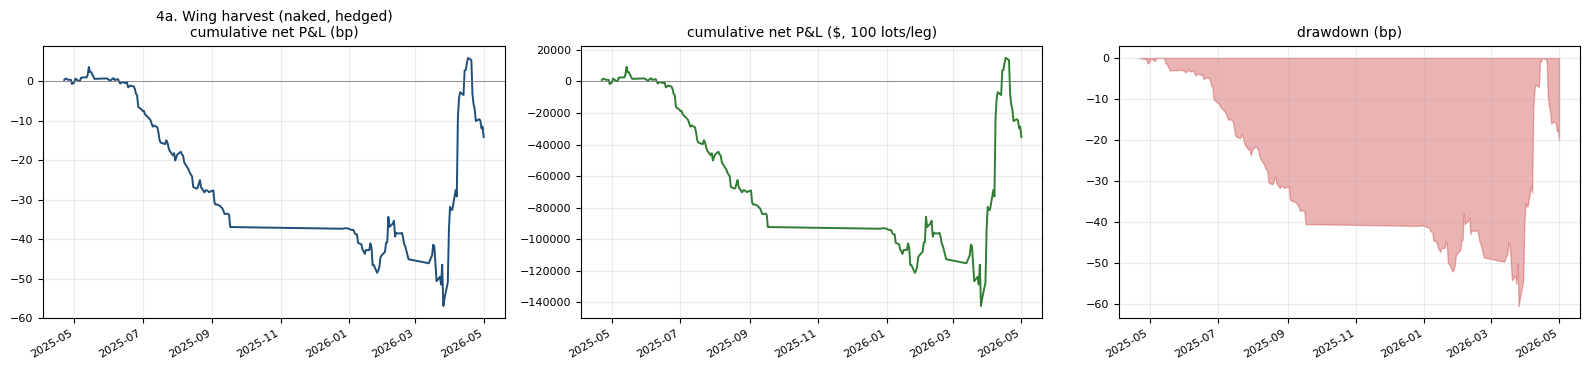


TRADE LOG (first rows)
   key  dir       structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp  net_bp   net_usd  stale_frac  pkg_contracts exit_reason
SFRZ26   -1 hikewing SFRZ26  2025-04-17 2025-04-21 2025-05-19    20  2.030    3.1410      2.5  0.6410   1602.55       0.304            1.0        time
SFRH27    1 hikewing SFRH27  2025-05-28 2025-05-29 2025-06-27    20 -2.606   -2.8204      2.5 -5.3204 -13300.93       0.301            1.0        time
SFRZ26    1 hikewing SFRZ26  2025-06-13 2025-06-16 2025-07-16    20 -2.052   -5.7118      2.5 -8.2118 -20529.54       0.257            1.0        time
SFRH27    1 hikewing SFRH27  2025-07-02 2025-07-03 2025-08-01    20 -2.007   -2.8873      2.5 -5.3873 -13468.32       0.347            1.0        time
SFRZ26    1 hikewing SFRZ26  2025-07-17 2025-07-18 2025-08-15    20 -2.814   -3.4249      2.5 -5.9249 -14812.16       0.349            1.0        time
SFRH27    1 hikewing SFRH27  2025-08-04 2025-08-05 2025-09-03    20 -2

signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        17           9.148       -33.352  -1.062     0.294
       listed    1        17          28.388       -14.112  -0.480     0.471
same-bar (lag 0) gross inflation: -210.3%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 17        28.388        1.67     0.588       70970.75
           0.5 17        19.888        1.17     0.588       49720.75
           1.0 17        11.388        0.67     0.588       28470.75
           1.5 17         2.888        0.17     0.588        7220.75
           2.5 17       -14.112       -0.83     0.471      -35279.25
           4.0 17       -39.612       -2.33     0.294      -99029.25

4a. Wing harvest (naked, hedged) — median config (not selected)  |  fade|ma1|w120|z1.5|t20|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 1 contracts -> position = 100 contr

In [5]:
out_naked = run_framework(
    "4a. Wing harvest (naked, hedged)", signals=_sig("hike_wing"),
    book=lab["book"], builder=builder_naked, base=BASE, grid_spec=GRID,
    params=PARAMS, cls="A",
    note=f"single {CONFIG['near_offset']*100:.0f}bp hike wing, daily delta hedge")

## 4b — wing vertical (sell the meat, own the disaster)

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 4b. Wing vertical (disaster buyback) — grid ===
  108 configs | median -90.81bp | IQR [-132.08, -64.84] | 0% net-positive | best -30.10bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   5            120               1.5        t20        19     0.158      -1.584       -30.096      -75240.75  -0.887    -31.624
 momentum  10            120               2.0        t20        14     0.143      -2.162       -30.269      -75673.50  -1.787    -31.780
     fade   1             60               2.0        t20        22     0.182      -1.417       -31.184      -77960.25  -0.539    -50.465
     fade   5            120               2.0        t20        14     0.000      -2.480       -34.726      -86816.25  -2.062    -35.316
 momentum   5            120               2.0        t20        14     0.071      -2.520       -

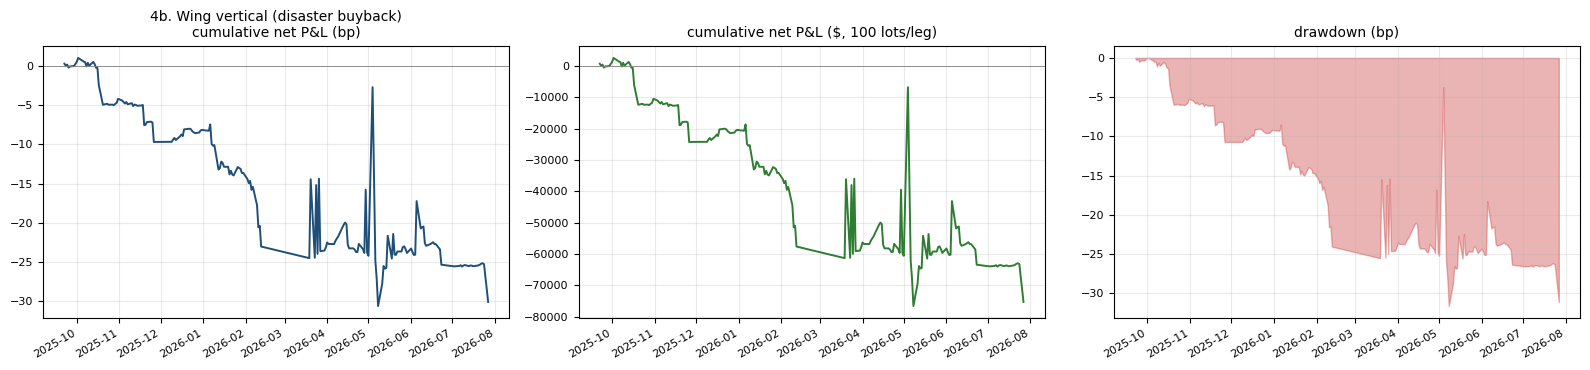


TRADE LOG (first rows)
   key  dir       structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp  net_bp   net_usd  stale_frac  pkg_contracts exit_reason
SFRZ26   -1 wingvert SFRZ26  2025-09-18 2025-09-19 2025-10-17    20 -1.844    0.0962      2.5 -2.4038  -6009.56       0.444            2.0        time
SFRH27   -1 wingvert SFRH27  2025-09-19 2025-09-22 2025-10-20    20 -1.940   -0.0607      2.5 -2.5607  -6401.72       0.432            2.0        time
SFRZ26    1 wingvert SFRZ26  2025-10-21 2025-10-22 2025-11-19    20  1.694    0.2981      2.5 -2.2019  -5504.79       0.576            2.0        time
SFRH27   -1 wingvert SFRH27  2025-10-28 2025-10-29 2025-11-26    20 -1.581   -0.0384      2.5 -2.5384  -6345.96       0.441            2.0        time
SFRZ26   -1 wingvert SFRZ26  2025-12-05 2025-12-08 2026-01-07    20 -1.558    1.4487      2.5 -1.0513  -2628.29       0.525            2.0        time
SFRH27   -1 wingvert SFRH27  2025-12-10 2025-12-11 2026-01-12    20 -1

exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0        23     0.130      -1.701       -39.130      -97825.50  -1.186    -40.136         15.087
half        23     0.087      -2.056       -47.277     -118191.75  -1.597    -48.283         14.652
  t5        47     0.000      -2.586      -121.556     -303891.00  -5.949   -121.823          4.915
 t10        31     0.000      -2.554       -79.190     -197973.75  -3.445    -80.196          9.710
 t20        19     0.158      -1.584       -30.096      -75240.75  -0.887    -31.624         18.895

MARKS x LAG
signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        20          -0.262       -50.262  -2.062     0.050
       listed    1        19          17.404       -30.096  -0.887     0.158
same-bar (lag 0) gross inflation: 6750.2%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total


  LEAGUE ROW  4b. Wing vertical (disaster buyback) / best-config: MARGINAL-maker-only  (taker -30.10bp, maker +17.40bp, DSR p=0.000)

  LEAGUE ROW  4b. Wing vertical (disaster buyback) / median-config: MARGINAL-maker-only  (taker -90.25bp, maker +12.25bp, DSR p=0.000)


In [6]:
out_vert = run_framework(
    "4b. Wing vertical (disaster buyback)", signals=_sig("wing_vertical"),
    book=lab["book"], builder=builder_vertical, base=BASE, grid_spec=GRID,
    params=PARAMS, cls="A",
    note=f"sell {CONFIG['near_offset']*100:.0f}bp / own "
         f"{CONFIG['far_offset']*100:.0f}bp, loss capped at the strike distance")

## 4c — strangle (wing level, no directional tilt)

  25/108 configs


  50/108 configs


  75/108 configs


  100/108 configs



=== 4c. Strangle (wing level) — grid ===
  108 configs | median -104.28bp | IQR [-166.73, -64.43] | 4% net-positive | best +34.11bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  zscore_window  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   1             60               1.5        t20        31     0.613       1.100        34.110       85274.50   0.348    -72.514
     fade  10            120               2.0        t20        13     0.538       2.472        32.135       80337.00   0.763    -62.728
     fade   5            120               2.0        t20        14     0.571       1.485        20.795       51988.50   0.417    -88.026
     fade   1            120               2.0        t20        14     0.357       1.335        18.692       46730.75   0.311    -98.818
 momentum   1             60               2.0        t20        19     0.474      -0.108        -2.044    

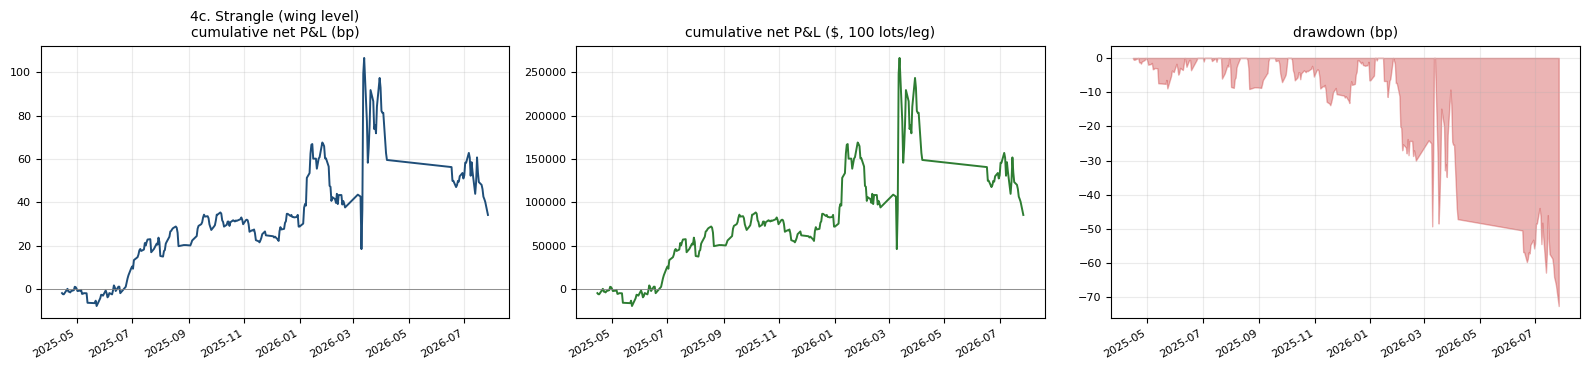


TRADE LOG (first rows)
   key  dir       structure signal_date      entry       exit  days   z_in  gross_bp  cost_bp  net_bp   net_usd  stale_frac  pkg_contracts exit_reason
SFRZ26    1 strangle SFRZ26  2025-04-11 2025-04-14 2025-05-13    20  1.851   -3.9452      2.5 -6.4452 -16112.88       0.158            2.0        time
SFRZ26   -1 strangle SFRZ26  2025-05-19 2025-05-20 2025-06-18    20 -1.695    5.2040      2.5  2.7040   6760.00       0.220            2.0        time
SFRH27   -1 strangle SFRH27  2025-05-19 2025-05-20 2025-06-18    20 -1.804    4.2297      2.5  1.7297   4324.29       0.220            2.0        time
SFRH27   -1 strangle SFRH27  2025-06-20 2025-06-23 2025-07-22    20 -1.657   11.4466      2.5  8.9466  22366.60       0.168            2.0        time
SFRZ26   -1 strangle SFRZ26  2025-06-20 2025-06-23 2025-07-22    20 -1.677   12.4572      2.5  9.9572  24893.06       0.172            2.0        time
SFRZ26   -1 strangle SFRZ26  2025-07-23 2025-07-24 2025-08-21    20 -1

exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0        32     0.562       0.771        24.679       61697.25   0.252    -79.541         18.656
half        34     0.529       0.415        14.124       35309.75   0.151    -88.141         16.588
  t5        78     0.308      -1.584      -123.552     -308880.00  -1.286   -163.442          5.000
 t10        53     0.302      -2.443      -129.458     -323644.25  -1.262   -158.998          9.849
 t20        31     0.613       1.100        34.110       85274.50   0.348    -72.514         19.290

MARKS x LAG
signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        32         108.927        28.927   0.307     0.500
       listed    1        31         111.610        34.110   0.348     0.613
same-bar (lag 0) gross inflation: -2.5%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_n


4c. Strangle (wing level) — median config (not selected)  |  fade|ma10|w60|z1.0|t20|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 2 contracts -> position = 200 contracts across all legs
  trades    41   skipped    0   hit 32%   avg -2.501bp   avg hold 18.4d   stale 22.0%
  total    -102.55bp   $    -256,382   gross -0.05bp
  daily-MTM Sharpe -0.82   maxDD -182.17bp ($-455,430)   worst trade -18.81bp
  t(trade) -1.95   NW t(daily) -0.88   non-overlap SR -0.87   DSR p=0.000 over 108 trials

  LEAGUE ROW  4c. Strangle (wing level) / best-config: SELECTION-ARTIFACT  (taker +34.11bp, maker +111.61bp, DSR p=0.015)

  LEAGUE ROW  4c. Strangle (wing level) / median-config: DEAD  (taker -102.55bp, maker -0.05bp, DSR p=0.000)


In [7]:
out_str = run_framework(
    "4c. Strangle (wing level)", signals=_sig("strangle"), book=lab["book"],
    builder=builder_strangle, base=BASE, grid_spec=GRID, params=PARAMS, cls="A",
    note="both wings, delta-hedged daily")

## FOMC conditioning

Does the wing premium behave differently into a meeting? Entries restricted to
the run-up, everything else unchanged.

eligible bars: 16.2%



=== 4d. Wing harvest (FOMC window) — grid ===
  16 configs | median -35.57bp | IQR [-79.19, -22.79] | 0% net-positive | best -13.65bp

  top rows (SELECTION-INFLATED — read the distribution above first):
direction  ma  entry_min_zscore exit_style  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
 momentum   1               1.5         t5        18     0.167      -0.758       -13.647      -34117.75  -1.085    -47.621
 momentum   5               1.0        t10        21     0.286      -0.810       -17.013      -42533.25  -0.669    -43.911
 momentum   1               1.5        t10        18     0.278      -0.956       -17.210      -43025.25  -0.760    -59.319
 momentum   5               1.0         t5        21     0.143      -0.825       -17.316      -43289.75  -1.190    -35.728
 momentum   5               1.5         t5        14     0.071      -1.758       -24.616      -61541.25  -3.040    -28.934
 momentum   1               1.0         t5        23     

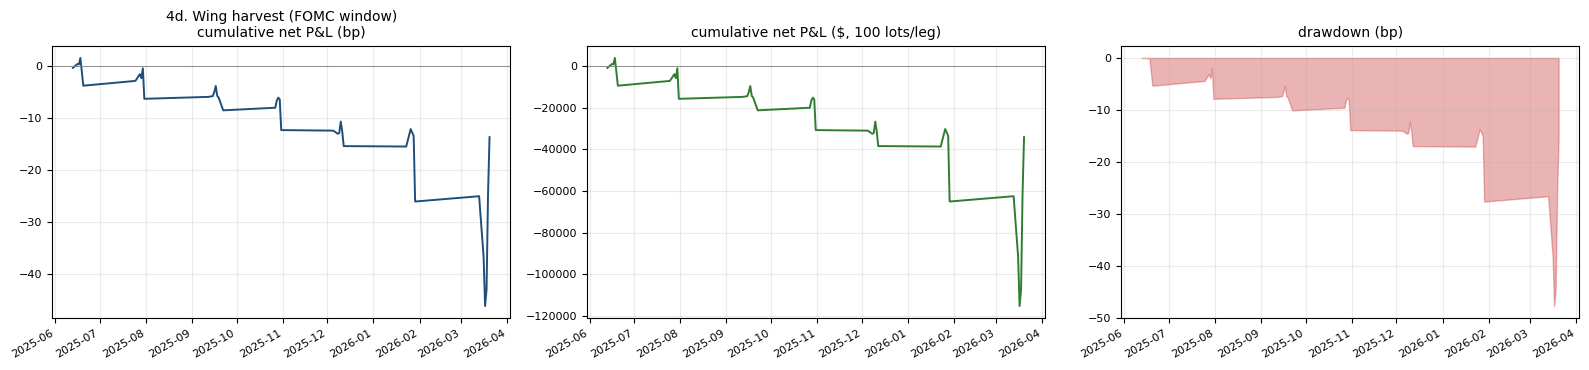


EXIT COMPARISON
exit  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp  avg_hold_days
  z0        18     0.167      -3.215       -57.874     -144685.00  -1.552    -70.467         19.000
half        18     0.167      -3.202       -57.627     -144067.50  -1.544    -70.220         18.833
  t5        18     0.167      -0.758       -13.647      -34117.75  -1.085    -47.621          5.000
 t10        18     0.278      -0.956       -17.210      -43025.25  -0.760    -59.319         10.000
 t20        18     0.167      -3.106       -55.911     -139776.75  -1.488    -68.504         20.000

MARKS x LAG


signal_source  lag  n_trades  total_gross_bp  total_net_bp  sharpe  hit_rate
       listed    0        18          28.802       -16.198  -1.699     0.056
       listed    1        18          31.353       -13.647  -1.085     0.167
same-bar (lag 0) gross inflation: -8.9%

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 18        31.353       1.742     0.833       78382.25
           0.5 18        22.353       1.242     0.722       55882.25
           1.0 18        13.353       0.742     0.500       33382.25
           1.5 18         4.353       0.242     0.222       10882.25
           2.5 18       -13.647      -0.758     0.167      -34117.75
           4.0 18       -40.647      -2.258     0.167     -101617.75

4d. Wing harvest (FOMC window) — median config (not selected)  |  fade|ma5|w120|z1.5|t10|lag1|every1|dh  |  100 contracts/leg ($2,500/bp)
  1 package = 1 contracts -> position = 100 contracts

In [8]:
ev = _sig("hike_wing")
ev["eligible"] = ev["days_to_fomc"].between(-7, -1)
print(f"eligible bars: {ev['eligible'].mean():.1%}")
out_ev = run_framework(
    "4d. Wing harvest (FOMC window)", signals=ev, book=lab["book"],
    builder=builder_naked, base=BASE,
    grid_spec={"direction": list(CONFIG["directions"]), "ma": [1, 5],
               "entry_min_zscore": [1.0, 1.5], "exit_style": ["t5", "t10"]},
    params=["direction", "ma", "entry_min_zscore", "exit_style"], cls="A",
    note="entries limited to 7 business days pre-FOMC", show_trades=0)